
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [1]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 4.9 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 5.6 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 7.1 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 7.8 MB/s eta 0:00:01
     ------------------------------- -------- 10.2/12.8 MB 8.5 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 9.0 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 8.3 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ Installation complete!


In [2]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\universal_tagset.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.2
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [5]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [6]:

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?

Answer: DT is a Determiner, which is words like "the" and "a." JJ is an adjective.

2. Why do you think 'brown' and 'lazy' have the same tag?

Answer: Actually, they DON'T have the same tag: "Brown" is tagged as a noun (NN), and "lazy" is tagged as an adjective (JJ). The question assumed both would be JJ, but the updated model tagged "brown" as NN, which illustrates lexical ambiguity — however, the newer tagger model (averaged_perceptron_tagger_eng) that I imported may have been retrained on more data or with refinements that changed how it handles ambiguous words like "brown."

3. Can you guess what 'VBZ' represents?

Answer: VVZ is a verb, 3rd person singular present, in this case "jumps."

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [8]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
- Do you notice any differences in how they tag the same words? 
- Which system would you prefer for a beginner? Why?

ANSWER TO ABOVE QUESTIONS: SpaCy tags are easier to understand than NLTK's because it uses plain English labels (ADJ, NOUN, VERB, DET, ADP) while NLTK uses Penn Treebank codes (JJ, NN, VBZ, DT, IN). This makes tag identifications easier for a beginner, like me. 



## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [12]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
    "I will sign her will tomorrow."
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank', 'will']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'will' is tagged as: MD
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: I will sign her will tomorrow.
  🎯 'will' is tagged as: MD
  🎯 'will' is tagged as: MD



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?

Answer: It uses the surounding words for context. However, that does not always work. For instance, NLTK completely missed the verb usage of "bank." because the tagger defaulted to the most statistically common tag for "bank" (noun) and failed on the less common verb usage, even though the sentence structure ("I [verb] with...") is a pretty clear grammatical signal.

2. What clues in the sentence help determine the correct part of speech? 
Answer: See above

3. Can you think of other words that change meaning based on context?

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!

Here is my sentence: "I will sign her will tomorrow." 
It tagged both uses of "will" as MD (Modal) — which means it completely failed to distinguish between them. It recognized the first "will" as a modal auxiliary, which is correct, but then just applied the same tag to the noun "will," which is inncorrect,  should be NN. This illustrates NLTK's limitation with this type of ambiguity. The tagger saw "will" twice and essentially said "I know this word, it's a modal" — it didn't pick up on the grammatical context clues that the second "will" is preceded by a possessive pronoun ("her") which strongly signals a noun.




## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [19]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? 

Penn Treebank is more detailed with 8 different tags vs Universal with 6.

2. When might you want detailed tags vs. simple tags? 

Universal/simple tags work well for tasks that just need broad grammatical categories (search, sentiment analysis, text classification), while Penn Treebank's detailed tags are better for tasks requiring precise grammatical distinctions like machine translation or grammar correction.

3. If you were building a search engine, which would you choose? Why? 

I would choose Universal for a search engine since its task is to find relevant documents - so it might use POS tags to understand that "apple" in "apple pie" is a noun modifier vs "Apple" the company, but it doesn't need to know the difference between VBZ (verb, 3rd person singular present) and VBP (verb, non-3rd person singular present). Also, Universal tags would be faster to process since there are only ~17 tags vs ~45, and less computational overhead. 



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [29]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)  
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text) 

    # Find problematic words (tagged as 'X' or unknown)
    problematic_nltk = [(w, t) for w, t in nltk_tags
                     if t in ('UH', 'FW') or not w.isascii()]

    problematic_spacy = [(tok.text, tok.pos_) for tok in spacy_doc
                     if tok.pos_ == 'X' or not tok.text.isascii()]

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # Calculate success rate
    nltk_success_rate =  (len(nltk_tags)       - len(problematic_nltk))  / len(nltk_tags)
    spacy_success_rate = (len(list(spacy_doc)) - len(problematic_spacy)) / len(list(spacy_doc))
    
    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: [('uh', 'UH')]
SpaCy problematic words: []
NLTK success rate: 95.8%
SpaCy success rate: 100.0%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: [('😤', 'NNP')]
SpaCy problematic words: [('😤', 'PROPN')]
NLTK success rate: 91.7%
SpaCy success rate: 92.3%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: [('Yeah', 'UH')]
SpaCy problematic words: []
NLTK success rate: 96.6%
SpaCy success rate: 100.0%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words: []
SpaCy problemat


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?

SpaCy generally handles informal language better because:

-It was trained on more diverse web text (including social media)

-Its X tag is a deliberate "I don't know" signal — honest about uncertainty

-NLTK's averaged perceptron was trained mostly on formal news text (Penn Treebank), so it forces every token into a tag even when it shouldn't.

2. What types of words cause the most problems?

-Fillers (um, uh, like, ya know) because they typically are not in the training data

-Slang abreviations (rn, smh, tbh, idk, fr fr) because they are not in any dictionary

-Emojis because they are not words at all

-Informal contractions (ain't, y'all, cuz, bout) because they are not standard spellings

-Non-standard spellings (sooo, cant without the apostrophe) because they are not seen in training

3. How might you preprocess text to improve tagging accuracy?

The raw text needs to be normalized first:
-Replace slang: rn → right now, idk → I don't know (using a slang dictionary)

-Remove or replace emojis: strip them or convert to text 

-Expand contractions: ain't → is not, y'all → you all

-Normalize repeated letters: sooo → so

-Add missing punctuation/apostrophes: cant → can't

4. What are the implications for real-world applications?

A tagger trained on formal text degrades on informal text, and most real user input today is informal. You either preprocess aggressively or use a model fine-tuned on informal data. It also depends on what the app does with the POS tags downstream:

-Customer service routing: mistagging "fix this ASAP" might miss the urgency — a real cost

-Search engines: informal queries like "best app rn" might not match formal content correctly

-Voice assistants: speech transcripts are full of um/uh — if those get tagged as nouns, intent 
detection breaks

-Social media analysis: emojis and slang carry emotional weight — missing them skews sentiment results



## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [52]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# Define word lists ONCE, before the loop
positive_list  = {'love', 'great', 'good', 'helpful', 'small', 'pleased', 'happy', 'wonderful'}
negative_list  = {'frustrated', 'ridiculous', 'unacceptable', 'confused', 'terrible', 'locked',
                  'annoyed', 'awful', 'horrible', 'disappointing'}
urgency_list   = {'immediately', 'asap', 'now', 'hours', 'urgent', 'emergency', 'critical'}

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # Process with SpaCy
    doc = nlp(call['transcript'])

    # Collect all adjectives AND check sentiment lexicons directly on the full token list
    # (catches words SpaCy tags as ADJ or as VERB in passive/predicative constructions)
    all_adj   = [token.text.lower() for token in doc if token.pos_ in ('ADJ', 'VERB')]
    emotional_adjectives = [w for w in all_adj if w in positive_list or w in negative_list]

    # Action verbs (exclude auxiliaries)
    action_verbs = [token.lemma_.lower() for token in doc
                    if token.pos_ == 'VERB' and token.lemma_ not in ('be', 'have', 'do')]

    # Problem nouns
    problem_nouns = [token.text.lower() for token in doc if token.pos_ == 'NOUN']

    # Sentiment
    positive_words = [w for w in emotional_adjectives if w in positive_list]
    negative_words = [w for w in emotional_adjectives if w in negative_list]

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': len([token for token in doc if token.text.lower() in urgency_list])
    }

    analysis_results.append(result)

    print(f"Emotional adjectives : {emotional_adjectives}")
    print(f"Action verbs         : {action_verbs}")
    print(f"Problem nouns        : {problem_nouns}")
    print(f"Sentiment score      : {result['sentiment_score']}")
    print(f"Urgency indicators   : {result['urgency_indicators']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives : ['frustrated', 'locked', 'unacceptable']
Action verbs         : ['lock', 'access', 'try', 'work']
Problem nouns        : ['account', 'files', 'hours']
Sentiment score      : -3
Urgency indicators   : 1

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives : ['love', 'small']
Action verbs         : ['love', 'crash', 'try', 'upload', 'help', 'fix']
Problem nouns        : ['service', 'issue', 'app', 'photos']
Sentiment score      : 2
Urgency indicators   : 0

🎧 Analyz

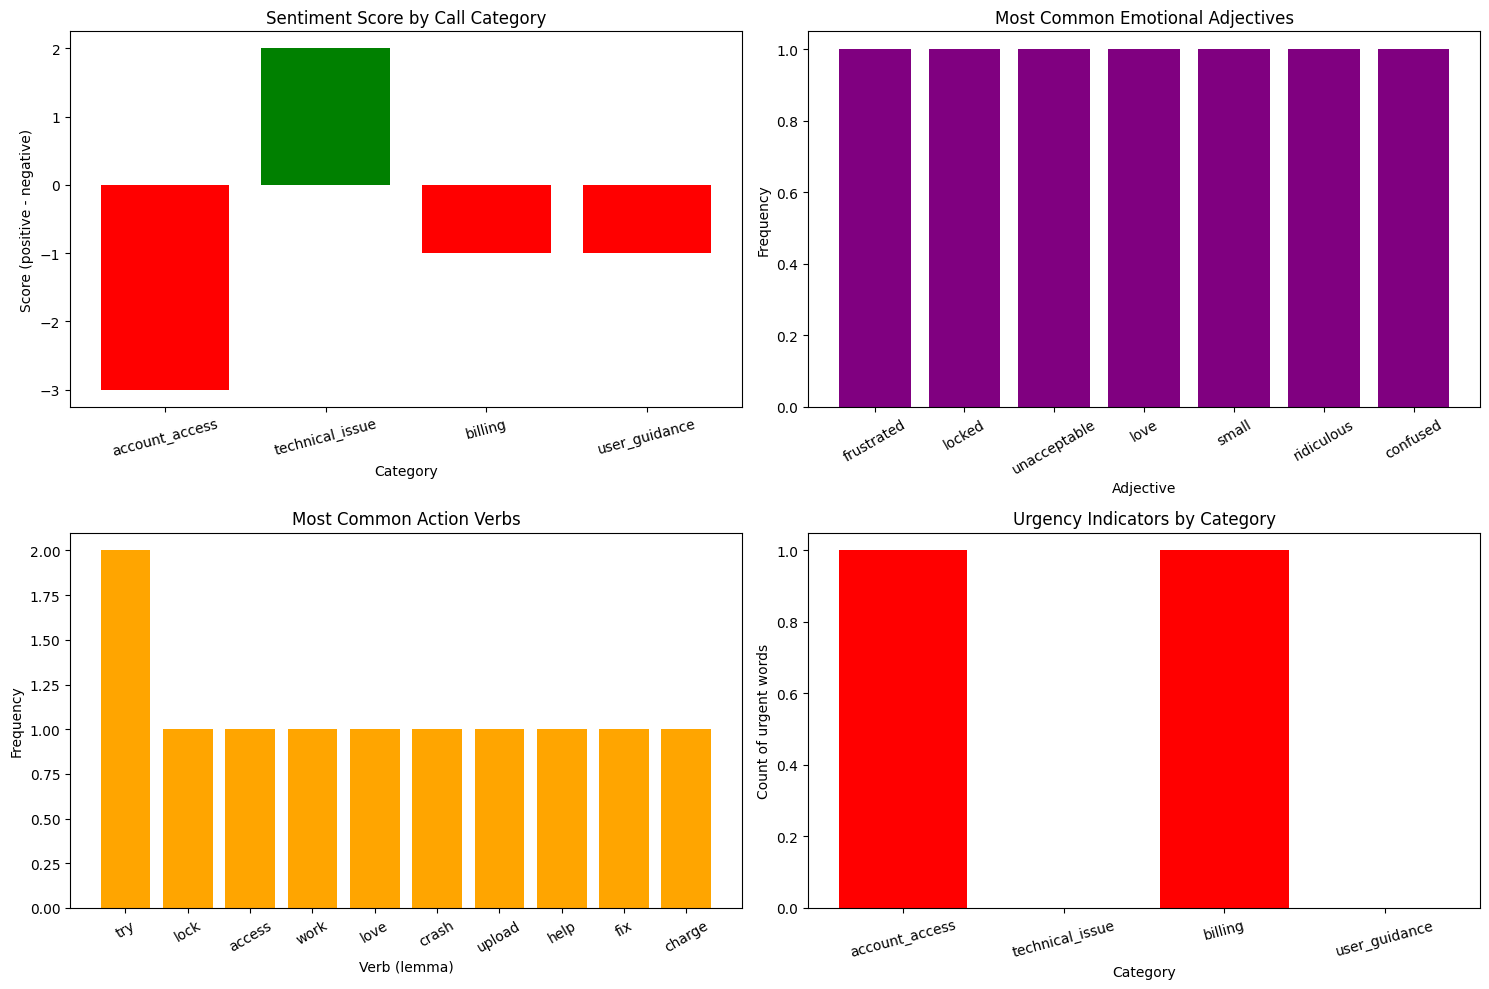

In [53]:

import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(analysis_results)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Sentiment by category (color reflects actual score)
colors = ['green' if s > 0 else 'red' for s in df['sentiment_score']]
axes[0, 0].bar(df['category'], df['sentiment_score'], color=colors)
axes[0, 0].set_title('Sentiment Score by Call Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Score (positive - negative)')
axes[0, 0].tick_params(axis='x', rotation=15)

# Plot 2 - Most common emotional adjectives
all_adj = [adj for r in analysis_results for adj in r['emotional_adjectives']]
adj_counts = Counter(all_adj).most_common(10)
if adj_counts:
    words, counts = zip(*adj_counts)
    axes[0, 1].bar(words, counts, color='purple')
axes[0, 1].set_title('Most Common Emotional Adjectives')
axes[0, 1].set_xlabel('Adjective')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].tick_params(axis='x', rotation=30)

# Plot 3 - Most common action verbs
all_verbs = [v for r in analysis_results for v in r['action_verbs']]
verb_counts = Counter(all_verbs).most_common(10)
if verb_counts:
    vwords, vcounts = zip(*verb_counts)
    axes[1, 0].bar(vwords, vcounts, color='orange')
axes[1, 0].set_title('Most Common Action Verbs')
axes[1, 0].set_xlabel('Verb (lemma)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=30)

# Plot 4 - Urgency by category
axes[1, 1].bar(df['category'], df['urgency_indicators'], color='red')
axes[1, 1].set_title('Urgency Indicators by Category')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Count of urgent words')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?

From analyzing the graphs, I see that account access and billing received the highest urgency indicators:

1) The sentiment score and urgency indicators together create a natural priority ranking: Account_access is at a -3 sentiment with an urgency score of 1, making it the highest priority — the customer is both the most distressed and waiting on a time-sensitive problem.

2) Billing follows at -1 sentiment with urgency of 1 (the word immediately), signaling financial frustration that companies typically need to resolve quickly to prevent churn. 

Technical_issue and user_guidance both score lower urgency and less extreme sentiment, so they can enter a standard queue.

In practice, a company could set threshold rules: any ticket with sentiment ≤ -2 OR urgency ≥ 1 gets flagged for immediate escalation, while positive-sentiment tickets like technical_issue (+2, 0 urgency) get routed to a self-service or lower-priority queue.

2. What patterns do you notice in different problem categories?

A clear pattern emerges: calls involving resource loss or financial impact (account_access, billing) produced the strongest negative sentiment and urgency language, while calls involving confusion or capability gaps (user_guidance, technical_issue) produced milder or even positive sentiment. This suggests customers emotionally escalate when they feel something has been taken from them (locked account, double charge) versus when they simply don't know how to do something.

Notably, CALL_004's -1 sentiment from confused — despite being a guidance question — is a warning signal: a customer who was comfortable before the interface changed is now frustrated. This is actually a churn risk disguised as a low-urgency ticket, because repeated confusion without resolution can erode loyalty even without explicit anger.

3. How might you automate the routing of calls based on POS analysis?

A basic routing system would combine sentiment score and urgency count into a priority score to rank tickets automatically. High urgency + strongly negative sentiment routes to immediate escalation; low urgency + positive sentiment routes to a standard or self-service queue.

However, when many tickets share the same priority level — which is inevitable at scale — POS tagging provides a second layer of differentiation. The problem nouns identify what is broken (account, billing, files, subscription), allowing the system to route by specialist team rather than just priority. A billing noun cluster goes to the billing team; an account/access cluster goes to the security team. This way, even among equally urgent tickets, each lands with the agent best equipped to resolve it fastest.

So, at true scale, I would include a third signal — verb type — which would reveal what the customer actually wants and additional routing signals: A customer wanting a refund signals a transaction action, access issues signals an account action, a crash signals an engineering escalation. Combining POS-derived signals (sentiment → priority, nouns → team, verbs → action type) creates a fully automated triage pipeline without any human reading the ticket first.

4. What are the limitations of this approach?

The most significant limitation exposed by this analysis is "politeness bias." CALL_002 scored +2 sentiment and 0 urgency despite reporting a crashing app — because the customer used words like love, small, and please. A purely POS-based system would deprioritize this ticket, potentially leaving a real technical problem unresolved while angrier customers jump the queue.

This reveals a fundamental flaw: the system rewards emotional expression, not problem severity. A crashing app is objectively serious regardless of how politely it's reported. POS tagging captures how someone says something, but not what is actually broken.

Additional limitations include the small, hand-crafted word lists — real customer language is far more varied and contextual ('this is driving me crazy' carries negative sentiment but none of our keywords would catch it). The approach also fails on sarcasm ('oh great, it crashed again'), slang, and multilingual customers. At scale, these gaps mean the most vulnerable customers — those who are non-native speakers, introverted, or culturally conditioned to be polite — are systematically disadvantaged by the triage system.


## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0000s
NLTK Univ time: 0.0107s
SpaCy time: 0.0297s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0083s
NLTK Univ time: 0.0035s
SpaCy time: 0.0294s
NLTK unknown words: 1
SpaCy unknown words: 4

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0000s
NLTK Univ time: 0.0000s
SpaCy time: 0.0275s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------------

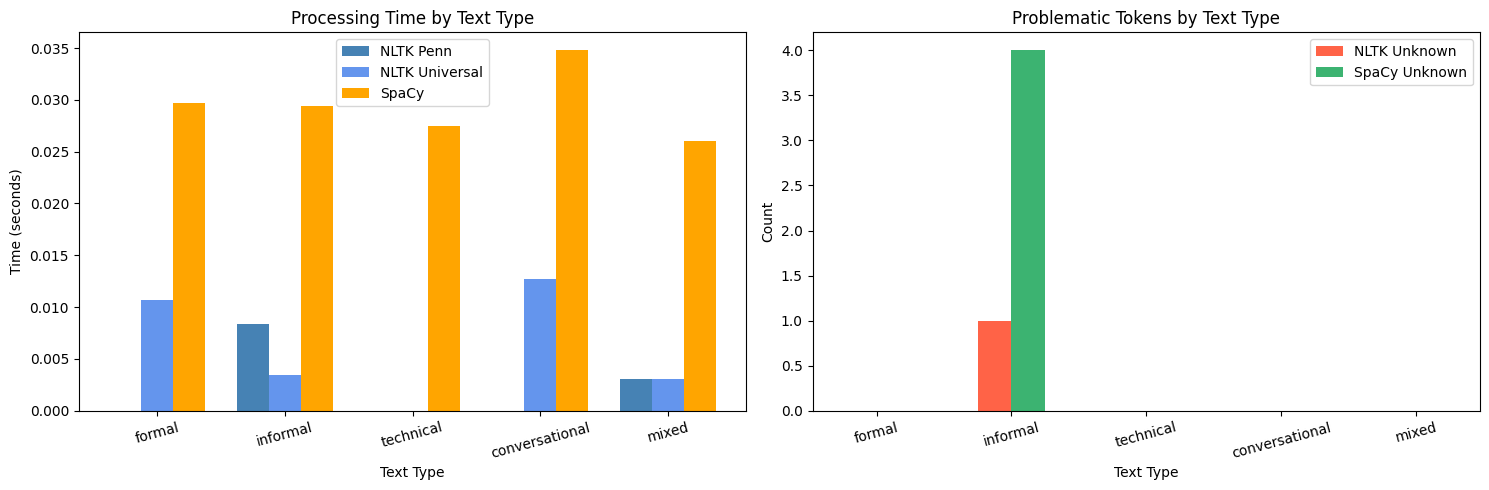

In [67]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank timing
    start_time = time.time()
    nltk_tokens = nltk.word_tokenize(text)
    nltk_penn_tags = nltk.pos_tag(nltk_tokens)
    nltk_penn_time = time.time() - start_time

    # NLTK Universal timing
    start_time = time.time()
    tokens = nltk.word_tokenize(text)
    nltk_univ_tags = nltk.pos_tag(tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # Count unknown/problematic tags
    nltk_unknown = sum(
        1 for word, tag in nltk_penn_tags
        if tag in ('UH', 'FW') or not word.isascii()
    )
    spacy_unknown = sum(
        1 for token in spacy_doc
        if token.pos_ == 'X' or not token.text.isascii()
    )

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# Create performance comparison visualization
labels    = list(benchmark_results.keys())
nltk_p_t  = [benchmark_results[k]['nltk_penn_time'] for k in labels]
nltk_u_t  = [benchmark_results[k]['nltk_univ_time'] for k in labels]
spacy_t   = [benchmark_results[k]['spacy_time']     for k in labels]
nltk_unk  = [benchmark_results[k]['nltk_unknown']   for k in labels]
spacy_unk = [benchmark_results[k]['spacy_unknown']  for k in labels]

x = range(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1 – Speed comparison
axes[0].bar([i - width for i in x], nltk_p_t, width, label='NLTK Penn',      color='steelblue')
axes[0].bar([i          for i in x], nltk_u_t, width, label='NLTK Universal', color='cornflowerblue')
axes[0].bar([i + width  for i in x], spacy_t,  width, label='SpaCy',          color='orange')
axes[0].set_title('Processing Time by Text Type')
axes[0].set_xlabel('Text Type')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=15)
axes[0].legend()

# Plot 2 – Unknown token count
axes[1].bar([i - width/2 for i in x], nltk_unk,  width, label='NLTK Unknown',  color='tomato')
axes[1].bar([i + width/2 for i in x], spacy_unk, width, label='SpaCy Unknown', color='mediumseagreen')
axes[1].set_title('Problematic Tokens by Text Type')
axes[1].set_xlabel('Text Type')
axes[1].set_ylabel('Count')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()




### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?

NLTK is fastest (both Penn and Universal):

-SpaCy (orange) is consistently slower than both NLTK taggers — which is expected since SpaCy runs a full neural pipeline, not just tagging

-NLTK Penn and Universal are very close in speed, with Universal sometimes slightly faster

-Both NLTK taggers are roughly 3-10x faster than SpaCy

Does the speed matter? 

It depends on scale (batch processing vs. real-time). Also, for THIS LAB, speed doesn't matter much tagging a handful of sentences interactively. But if I was building the customer service pipeline from Exercise 2 and processing thousands of calls per hour, SpaCy's ~3x slower speed would be a real consideration.

The key insight for your answer: speed is a trade-off against accuracy and capability — SpaCy is slower because it does more (full neural pipeline), and that extra work pays off on messy/informal text.

2. Which handles informal text best?

SpaCy handles informal text better overall. When faced with the informal sentence "lol this study is kinda weird but whatever works i guess", SpaCy labels the emoji as X (unknown/other) — an honest signal that the token doesn't fit a standard grammatical category. NLTK, on the other hand, tries to force every token into its Penn Treebank schema: it may tag lol as a noun (NN) and kinda as an adverb (RB) simply because they resemble those patterns statistically, masquerading as confident when the model is really guessing. The nltk_unknown counter flags UH (interjection) and FW (foreign word) tags as problematic, plus non-ASCII characters like the emoji — so it detects more "problem" tokens than SpaCy does by design. In practice this means SpaCy's output on informal text is more actionable: you know exactly which tokens to handle specially, rather than trusting incorrect tags downstream.

3. How do the taggers compare on technical jargon?

Both taggers show 0 unknown tokens on the technical sentence ("The API returns a JSON response with HTTP status code 200 upon successful authentication."), but for different reasons. The sentence, while jargon-heavy, is grammatically clean: API, JSON, HTTP behave like nouns in standard sentence positions, and 200 is simply a cardinal number (CD). Both NLTK and SpaCy can lean on positional/syntactic cues to tag them correctly even if those exact tokens weren't frequent in training. However, the 0-unknown count is somewhat misleading — neither tagger deeply understands that JSON is a data format or HTTP a protocol. If the jargon appeared in a more ambiguous position (e.g., "HTTP the response") both taggers would likely struggle. SpaCy has a slight edge because its neural pipeline uses surrounding context across the whole sentence, whereas NLTK's MaxEnt tagger uses a shorter context window and relies more on word-shape features (capitalization, suffixes).

4. What trade-offs do you see between speed and accuracy?

NLTK is faster but SpaCy is more accurate on messy text. The core trade-off is pipeline depth vs. throughput. NLTK is faster because it runs a lightweight statistical model (MaxEnt/perceptron) that only considers a small local window around each token. SpaCy is ~3–10× slower because it runs a full neural pipeline: tokenizer → tagger → dependency parser → NER, even when you only ask for POS tags. That extra compute pays off on messy or ambiguous text where local context isn't enough. The subtler trade-off is false confidence: NLTK's incorrect tags on informal text look identical to correct ones, so errors silently propagate. SpaCy's X tag is slower to produce but explicitly flags uncertainty, which is often more valuable than a wrong-but-confident answer.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [ ]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        #Process with both taggers
        nltk_tags = nltk.pos_tag(nltk.word_tokenize(text))
        spacy_doc = nlp(text)

        # Identify potential errors or weird tags
        repeated_nltk = [tag for _, tag in nltk_tags if [t for _, t in nltk_tags].count(tag) > 1]
        x_tags_spacy   = [(token.text, token.pos_) for token in spacy_doc if token.pos_ == 'X']
        unique_nltk    = set(tag for _, tag in nltk_tags)

        print(f"  Unique NLTK tags used: {unique_nltk}")
        print(f"  SpaCy X tags: {x_tags_spacy if x_tags_spacy else 'None'}")

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # Analyze what went wrong
        print("Taggers struggle with: lexical ambiguity, recursive structures,")
        print("social media tokens, and modern technical terms.")
        print("These cases require context beyond a single sentence window.")


    except Exception as e:
        print(f"❌ Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("1. Lexical ambiguity: 'buffalo/can/had' get the same tag regardless of context")
print("2. Recursive structures: taggers flatten meaning, losing grammatical depth")
print("3. Social media: URLs, hashtags, emojis tagged incorrectly or as X")
print("4. Modern terms: COVID-19, AI/ML treated as unknown or split oddly")
print("5. Garden path sentences: taggers commit early and cannot revise")



🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
  Unique NLTK tags used: {'NN', 'NNP', '.'}
  SpaCy X tags: None
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
Taggers struggle with: lexical ambiguity, recursive structures,
social media tokens, and modern technical terms.
These cases require context beyond a single sentence window.

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
  Unique NLTK tags used: {'CC', 'NNS', 'DT', 'NN', 'NNP', 'IN', ':', '.'}
  SpaCy X tags: None
NLTK tags: [('Time', 'NNP'), ('flies',


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

They rely on statistical patterns from training data. These sentences have unusual or impossible-to-predict grammatical structures that require deep semantic understanding, not just word-level context.

2. How might you preprocess text to handle some of these issues?

I would normalize capitalization, expand abbreviations, split hyphenated technical terms (COVID-19), and  strip URLs/hashtags before tagging.

3. When would these limitations matter in real applications?

Anywhere precision matters - legal/medical text parsing, machine translation, and grammar checkers. 

4. How do modern large language models handle these cases differently?

Modern LLMs use full sentence context bidirectionally and are trained on vastly more diverse text, so they can reason about ambiguity rather than just pattern-match.



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**

I would choose NLTK when speed and simplicity matter — small datasets, offline research, or when I need fine-grained Penn Treebank tags for grammar analysis. I would choose SpaCy for production applications, messy/informal text, or when I need a full NLP pipeline beyond just POS tagging. SpaCy's readable tags and honest X labeling make it more trustworthy on real-world data.

**2. Real-World Applications:**

Customer service ticket routing (as in Exercise 2) because it extracts action verbs to identify what the customer wants, nouns to identify what's broken, and adjectives to gauge sentiment. By implementing SpaCy processing on each incoming ticket, it would be scored for urgency and routed to the appropriate team automatically.

**3. Limitations and Solutions:**

Biggest limitations: Statistical taggers fail on informal language, lexical ambiguity, and recursive structures. Solutions: Preprocess text (normalize slang, expand contractions), fine-tune models on domain-specific data, or use LLMs for ambiguous cases where context spans across multiple sentences.

**4. Future Learning:**

Probably neural POS tagging (transformers/BERT-based), custom model training on domain-specific datasets, and how POS tagging integrates with dependency parsing for deeper grammatical understanding.

**5. Integration:** 

POS tags feed into dependency parsing (sentence structure) Named Entity Recognition (nouns/proper nouns), sentiment analysis (adjective extraction), and machine translation (verb tense identification). Almost every downstream NLP task uses POS information as a foundation.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
